# Assignments: Cleaning Data

## 1. Data in Python Request

* Read in data from the Excel spreadsheet (Alarm Survey Data.xlsx) and put into a Pandas DataFrame
* Check the data type of each column
* Convert object columns into numeric or datetime columns, as needed

In [153]:
import pandas as pd

In [154]:
df = pd.read_excel('Alarm Survey Data.xlsx')
df.head()

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
0,1,34,3.0,active,3.0,1,5 stars
1,2,31,3.0,light,3.0,3,3 stars
2,3,18,0.0,light_activity,4.0,1,1 stars
3,4,42,4.0,active,4.0,1,4 stars
4,5,30,1.0,light_activity,1.0,4,3 stars


In [155]:
df.dtypes

survey_id               int64
age                     int64
number_of_children    float64
activity_level         object
sleep_quality         float64
number_of_snoozes       int64
alarm_rating           object
dtype: object

In [156]:
# change the alarm rating column to a numeric column
df.alarm_rating = pd.to_numeric(df.alarm_rating.str.replace(' stars', ''))
df

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
0,1,34,3.0,active,3.0,1,5
1,2,31,3.0,light,3.0,3,3
2,3,18,0.0,light_activity,4.0,1,1
3,4,42,4.0,active,4.0,1,4
4,5,30,1.0,light_activity,1.0,4,3
...,...,...,...,...,...,...,...
6428,6362,27,2.0,active,5.0,0,5
6429,6363,31,1.0,light,4.0,0,4
6430,6364,26,0.0,lightly active,5.0,0,3
6431,6365,27,1.0,active,5.0,0,3


In [157]:
df.dtypes

survey_id               int64
age                     int64
number_of_children    float64
activity_level         object
sleep_quality         float64
number_of_snoozes       int64
alarm_rating            int64
dtype: object

In [158]:
# changing 'number_of_children' = float -> int
df.number_of_children = df.number_of_children.astype('int')
df.head()

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
0,1,34,3,active,3.0,1,5
1,2,31,3,light,3.0,3,3
2,3,18,0,light_activity,4.0,1,1
3,4,42,4,active,4.0,1,4
4,5,30,1,light_activity,1.0,4,3


## 2. Missing Data Check

* Find any missing data
* Deal with the missing data

In [159]:
# checking for missing data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   survey_id           6433 non-null   int64  
 1   age                 6433 non-null   int64  
 2   number_of_children  6433 non-null   int64  
 3   activity_level      6433 non-null   object 
 4   sleep_quality       6082 non-null   float64
 5   number_of_snoozes   6433 non-null   int64  
 6   alarm_rating        6433 non-null   int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 351.9+ KB


In [160]:
# displaying rows with missing values
df[df.isna().any(axis=1)]
# 'sleep_quality' has missing values displayed as NaN

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
10,11,28,2,light_activity,NaN,3,4
18,19,38,2,lightly active,NaN,1,5
23,24,24,2,very active,NaN,1,5
26,27,25,2,lightly active,NaN,1,2
28,29,29,2,lightly active,NaN,1,2
...,...,...,...,...,...,...,...
6310,6311,30,2,very active,NaN,0,3
6319,6320,44,2,lightly active,NaN,0,3
6375,6309,32,3,light,NaN,0,3
6377,6311,30,2,very active,NaN,0,3


In [161]:
# return missing values by column
df.isna().sum()
# 351 missing values in 'sleep_quality'

survey_id               0
age                     0
number_of_children      0
activity_level          0
sleep_quality         351
number_of_snoozes       0
alarm_rating            0
dtype: int64

In [162]:
# looking at sleep quality values
df.sleep_quality.value_counts(dropna=False)
# 2.0 is missing

sleep_quality
5.0    2721
4.0    2261
3.0     997
NaN     351
1.0     103
Name: count, dtype: int64

In [163]:
# update sleep quality NaNs to 2
df.sleep_quality.fillna(2, inplace=True)

C:\Users\lassa\AppData\Local\Temp\ipykernel_2004\1555142042.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.sleep_quality.fillna(2, inplace=True)


In [164]:
# sleep quality values
df.sleep_quality.value_counts(dropna=False)

sleep_quality
5.0    2721
4.0    2261
3.0     997
2.0     351
1.0     103
Name: count, dtype: int64

In [165]:
df

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
0,1,34,3,active,3.0,1,5
1,2,31,3,light,3.0,3,3
2,3,18,0,light_activity,4.0,1,1
3,4,42,4,active,4.0,1,4
4,5,30,1,light_activity,1.0,4,3
...,...,...,...,...,...,...,...
6428,6362,27,2,active,5.0,0,5
6429,6363,31,1,light,4.0,0,4
6430,6364,26,0,lightly active,5.0,0,3
6431,6365,27,1,active,5.0,0,3


## 3. Inconsistent Text & Typos Check

* Find any inconsistent text and typos
* Deal with the inconsistent text and typos

In [166]:
df.head()

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
0,1,34,3,active,3.0,1,5
1,2,31,3,light,3.0,3,3
2,3,18,0,light_activity,4.0,1,1
3,4,42,4,active,4.0,1,4
4,5,30,1,light_activity,1.0,4,3


In [167]:
# check the numerical columns
df.describe()

,survey_id,age,number_of_children,sleep_quality,number_of_snoozes,alarm_rating
count,6433.000000,6433.000000,6433.000000,6433.000000,6433.000000,6433.000000
mean,3216.302192,29.069175,1.379761,4.110835,1.145811,2.955075
std,1856.007409,7.472048,1.388768,0.963415,1.599481,1.101363
min,1.000000,13.000000,0.000000,1.000000,0.000000,1.000000
25%,1609.000000,23.000000,0.000000,4.000000,0.000000,2.000000
50%,3217.000000,28.000000,1.000000,4.000000,0.000000,3.000000
75%,4825.000000,34.000000,2.000000,5.000000,2.000000,4.000000
max,6366.000000,47.000000,5.000000,5.000000,19.000000,5.000000


In [168]:
df.number_of_children.value_counts()

number_of_children
0    2440
2    1498
1    1172
3     788
4     331
5     204
Name: count, dtype: int64

In [169]:
df.activity_level.value_counts()

activity_level
active            2450
lightly active    2289
light_activity     691
very active        669
light              334
Name: count, dtype: int64

### Inconsistencies:
- light, lightly active and light_activity = the same

In [170]:
# map the lightly active values to one value
import numpy as np

df.activity_level = np.where(df.activity_level.isin(['light_activity', 'light']), 
                             'lightly active',
                             df.activity_level)
df

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
0,1,34,3,active,3.0,1,5
1,2,31,3,lightly active,3.0,3,3
2,3,18,0,lightly active,4.0,1,1
3,4,42,4,active,4.0,1,4
4,5,30,1,lightly active,1.0,4,3
...,...,...,...,...,...,...,...
6428,6362,27,2,active,5.0,0,5
6429,6363,31,1,lightly active,4.0,0,4
6430,6364,26,0,lightly active,5.0,0,3
6431,6365,27,1,active,5.0,0,3


In [171]:
# check categorical columns
df.activity_level.value_counts()

activity_level
lightly active    3314
active            2450
very active        669
Name: count, dtype: int64

## 4. Duplicate Data Check

* Find any duplicate data
* Deal with the duplicate data

In [172]:
df.shape

(6433, 7)

In [173]:
df.duplicated().sum()

np.int64(67)

In [174]:
df[df.duplicated()]

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
6366,6300,31,2,active,5.0,0,3
6367,6301,27,2,lightly active,4.0,0,2
6368,6302,41,3,lightly active,5.0,0,2
6369,6303,25,0,lightly active,5.0,0,5
6370,6304,25,1,lightly active,5.0,0,2
...,...,...,...,...,...,...,...
6428,6362,27,2,active,5.0,0,5
6429,6363,31,1,lightly active,4.0,0,4
6430,6364,26,0,lightly active,5.0,0,3
6431,6365,27,1,active,5.0,0,3


In [175]:
df = df.drop_duplicates()
df

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
0,1,34,3,active,3.0,1,5
1,2,31,3,lightly active,3.0,3,3
2,3,18,0,lightly active,4.0,1,1
3,4,42,4,active,4.0,1,4
4,5,30,1,lightly active,1.0,4,3
...,...,...,...,...,...,...,...
6361,6362,27,2,active,5.0,0,5
6362,6363,31,1,lightly active,4.0,0,4
6363,6364,26,0,lightly active,5.0,0,3
6364,6365,27,1,active,5.0,0,3


In [176]:
df.duplicated().sum()

np.int64(0)

In [177]:
'''
alternative: save non-duplicates
df = df[~df.duplicated()]
df
'''

'\nalternative: save non-duplicates\ndf = df[~df.duplicated()]\ndf\n'

In [178]:
6366 + 67 # = 6433, the original number of rows

6433

## 5. Outliers Check

* Find any outliers
* Deal with the outliers

In [179]:
import seaborn as sns

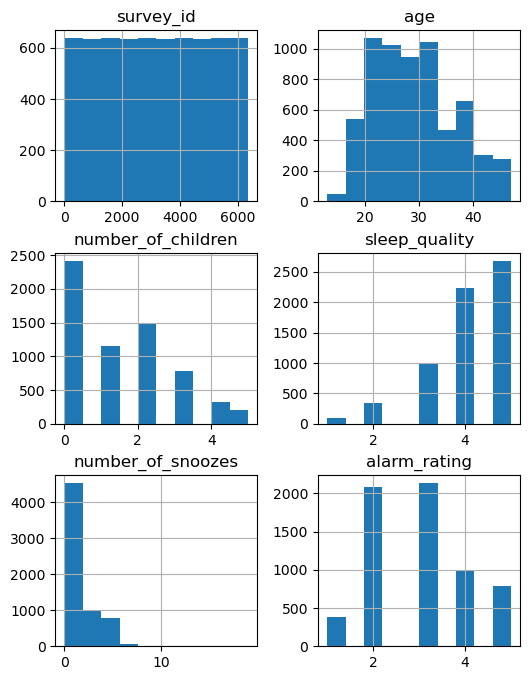

In [180]:
# histograms of all numeric columns
df.hist(figsize = (6,8));

### Number of Snoozes Outliers

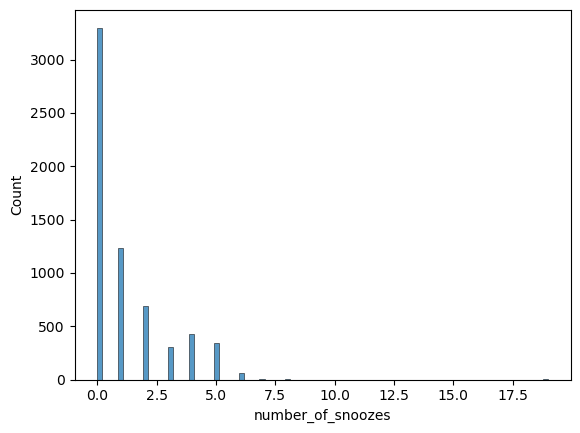

In [181]:
# histogram of number of snoozes
sns.histplot(df.number_of_snoozes);

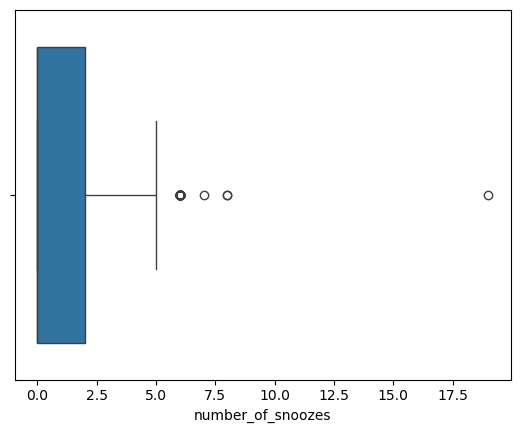

In [182]:
# box plot of number_of_snoozes
sns.boxplot(x=df.number_of_snoozes);

In [183]:
df.number_of_snoozes.value_counts()

# number of snoozes on the left and the number of people snoozing is to the right
# the 1 person snoozing 19 times is an outlier

number_of_snoozes
0     3300
1     1229
2      693
4      427
5      345
3      309
6       59
8        2
19       1
7        1
Name: count, dtype: int64

In [184]:
# the outlier
df[df.number_of_snoozes >= 19]


,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
749,750,19,1,lightly active,5.0,19,3


In [185]:
# removing the outlier
df = df[df.number_of_snoozes < 19]
df

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating
0,1,34,3,active,3.0,1,5
1,2,31,3,lightly active,3.0,3,3
2,3,18,0,lightly active,4.0,1,1
3,4,42,4,active,4.0,1,4
4,5,30,1,lightly active,1.0,4,3
...,...,...,...,...,...,...,...
6361,6362,27,2,active,5.0,0,5
6362,6363,31,1,lightly active,4.0,0,4
6363,6364,26,0,lightly active,5.0,0,3
6364,6365,27,1,active,5.0,0,3


## 6. Data Issues Check

* Quickly explore the updated DataFrame. How do things look now after handling the data issues compared to the original DataFrame?

In [186]:
# check for missing values
df[df.isna().any(axis=1)]

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating


In [187]:
# check for inconsistent text and typos
df.activity_level.value_counts()

activity_level
lightly active    3287
active            2422
very active        656
Name: count, dtype: int64

In [188]:
# check for duplicate data
df[df.duplicated()]

,survey_id,age,number_of_children,activity_level,sleep_quality,number_of_snoozes,alarm_rating


In [189]:
# check for outliers
df.describe()

,survey_id,age,number_of_children,sleep_quality,number_of_snoozes,alarm_rating
count,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000
mean,3183.882325,29.076826,1.380990,4.107620,1.155067,2.955224
std,1837.741432,7.476376,1.389956,0.963612,1.587979,1.100414
min,1.000000,13.000000,0.000000,1.000000,0.000000,1.000000
25%,1593.000000,23.000000,0.000000,4.000000,0.000000,2.000000
50%,3184.000000,28.000000,1.000000,4.000000,0.000000,3.000000
75%,4775.000000,34.000000,2.000000,5.000000,2.000000,4.000000
max,6366.000000,47.000000,5.000000,5.000000,8.000000,5.000000


## 7. Create Columns From Numeric Data

* Read data into Python
* Check the data type of each column
* Create a numeric column using arithmetic
* Create a numeric column using conditional logic

In [191]:
# Create a “Total Spend” column that includes both the pen cost and shipping cost for each sale
# Create a “Free Shipping” column that says yes if the sale included free shipping, and no otherwise

In [194]:
pen_sales = pd.read_excel('Pen Sales Data.xlsx')

In [195]:
pen_sales.head()

,Customer,Item,Pen Cost,Shipping Cost,Purchase Date,Delivery Date,Review
0,5201,Ballpoint Pens,5.99,2.99,2023-05-01,2023-05-03,"DoodleWithMe|I love the way this pen writes, b..."
1,5202,Sharpies,12.99,0.00,2023-05-01,2023-05-04,ScribbleMaster|The classic Sharpie marker has ...
2,5203,Ballpoint Pens (Bold),6.95,4.99,2023-05-01,2023-05-02,PenPalForever|The retractable ballpoint pen ha...
3,5204,Gel Pens,5.99,2.99,2023-05-01,2023-05-04,TheWriteWay|This gel pen has a comfortable gri...
4,5205,Rollerball Pens,12.99,1.99,2023-05-01,2023-05-03,PenAndPaperPerson|The rollerball pen has a smo...


In [197]:
pen_sales.dtypes

Customer                  int64
Item                     object
Pen Cost                float64
Shipping Cost           float64
Purchase Date    datetime64[ns]
Delivery Date    datetime64[ns]
Review                   object
dtype: object

In [199]:
# 'Total Spend' column
pen_sales['Total Spend'] = pen_sales['Pen Cost'] + pen_sales['Shipping Cost']
pen_sales.head()

,Customer,Item,Pen Cost,Shipping Cost,Purchase Date,Delivery Date,Review,Total Spend
0,5201,Ballpoint Pens,5.99,2.99,2023-05-01,2023-05-03,"DoodleWithMe|I love the way this pen writes, b...",8.98
1,5202,Sharpies,12.99,0.00,2023-05-01,2023-05-04,ScribbleMaster|The classic Sharpie marker has ...,12.99
2,5203,Ballpoint Pens (Bold),6.95,4.99,2023-05-01,2023-05-02,PenPalForever|The retractable ballpoint pen ha...,11.94
3,5204,Gel Pens,5.99,2.99,2023-05-01,2023-05-04,TheWriteWay|This gel pen has a comfortable gri...,8.98
4,5205,Rollerball Pens,12.99,1.99,2023-05-01,2023-05-03,PenAndPaperPerson|The rollerball pen has a smo...,14.98


In [202]:
# Create a “Free Shipping” column that says yes if the sale included free shipping,
# and no otherwise
pen_sales['Free Shipping'] = np.where(
    pen_sales['Shipping Cost'] == 0, 'Yes', 'No'
              )
pen_sales.head()

,Customer,Item,Pen Cost,Shipping Cost,Purchase Date,Delivery Date,Review,Total Spend,Free Shipping
0,5201,Ballpoint Pens,5.99,2.99,2023-05-01,2023-05-03,"DoodleWithMe|I love the way this pen writes, b...",8.98,No
1,5202,Sharpies,12.99,0.00,2023-05-01,2023-05-04,ScribbleMaster|The classic Sharpie marker has ...,12.99,Yes
2,5203,Ballpoint Pens (Bold),6.95,4.99,2023-05-01,2023-05-02,PenPalForever|The retractable ballpoint pen ha...,11.94,No
3,5204,Gel Pens,5.99,2.99,2023-05-01,2023-05-04,TheWriteWay|This gel pen has a comfortable gri...,8.98,No
4,5205,Rollerball Pens,12.99,1.99,2023-05-01,2023-05-03,PenAndPaperPerson|The rollerball pen has a smo...,14.98,No


## 8. Create Columns From DateTime Data

* Calculate the difference between two datetime columns and save it as a new column
* Take the average of a column

In [192]:
# Calculate the number of days between the purchase and delivery date for each sale
# Save it as a new column called “Delivery Time”
# What were the average days from purchase to delivery?

## 9. Create Columns From Text Data

* Split one column into multiple columns
* Create a Boolean column (True / False) to show whether a text field contains particular words

In [193]:
# Split the reviews on the “|” character to create two new columns: “User Name” and “Review Text”
# Create a “Leak or Spill” column that flags the reviews that mention either “leak” or “spill”